# Case Studies: Behavioral Response to a Respiratory Epidemic (Part 3)

## Introduction

In Parts 1 and 2 we ran epidemics on static networks where agent behavior never changed. Here we study a **closed community of 1,000 individuals** connected in a **small-world** contact network (mean degree ≈ 10), and let people *react* to the outbreak.

**Scenario:** a respiratory pathogen spreads through the community. Some infections become severe and require **hospitalization**. As hospitalizations mount, the perceived severity of the disease rises, and individuals begin to **restrict their contacts** (distancing, staying home, avoiding crowds). This is an adaptive, self-limiting feedback loop.

Two ingredients drive the model:

1. **Hospitalization dynamics (SIHR model)** — a fraction of infected individuals develop severe disease and are admitted to hospital, where they are isolated (no further transmission) until they recover.
2. **Hospitalization-driven behavior** — each day, individuals who have *not yet* adopted contact-restricting behavior decide whether to adopt it. The probability rises with the share of the community currently hospitalized. Once adopted, the behavior is kept (an absorbing state), and the individual **halves their contacts**.

### Model compartments

| Symbol | Meaning |
|--------|---------|
| **S** | Susceptible — not yet infected |
| **I** | Infected — infectious, circulating in the community |
| **H** | Hospitalized — severe case, isolated and removed from transmission |
| **R** | Recovered — immune |

### The behavioral feedback loop

> ↑ hospitalizations → ↑ perceived severity → ↑ contact restriction → ↓ transmission → ↓ hospitalizations

We first establish the SIHR baseline (Section A), then layer the behavioral response on top and explore how its parameters shape the epidemic (Section B).

## Setup

In [1]:
cd(@__DIR__)

# Per-notebook output directories
const FIGURES_DIR = "figures/part3"
const DATA_DIR    = "data/part3"

mkpath(FIGURES_DIR)
mkpath(DATA_DIR)
mkpath("output")

using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using Agents, Graphs, Random, Plots, DataFrames, CSV,
      Statistics, StatsBase, StatsPlots, Measures, CategoricalArrays

include("src/create_graph.jl")

@agent struct Person(GraphAgent)
    status::Symbol       = :S
    days_infected::Int   = 0
    contact_rate::Symbol = :high
end

include("src/initialize.jl")
include("src/agent_step.jl")

function model_step!(model::AgentBasedModel)
    model.susceptible_count  = sum(model[i].status == :S for i in 1:nv(model.graph))
    model.infected_count     = sum(model[i].status == :I for i in 1:nv(model.graph))
    model.hospitalized_count = sum(model[i].status == :H for i in 1:nv(model.graph))
    model.recovered_count    = sum(model[i].status == :R for i in 1:nv(model.graph))
end

  Activating project at `c:\Users\Leonard\julia-workspace\espidam-tutorial-2026`


model_step! (generic function with 1 method)

---
## Section A: Baseline Community Outbreak (SIHR Model)

We begin without any behavioral response, to establish a baseline. All 1,000 individuals sit on a **small-world** network (mean degree ≈ 10), giving high local clustering with a few long-range shortcuts — a reasonable caricature of community contact.

The SIHR model adds a hospitalization stage: with probability `hospitalization_prob`, a newly infected agent develops severe disease and is admitted to hospital on day 1 instead of continuing to circulate. Hospitalized agents are isolated (do not transmit) and recover after `days_to_hospital_recovery` days.

We compare:
- **SIR** (`use_hospitalization=false`): everyone circulates until recovery
- **SIHR** (`use_hospitalization=true`): a fraction of infections are removed to hospital

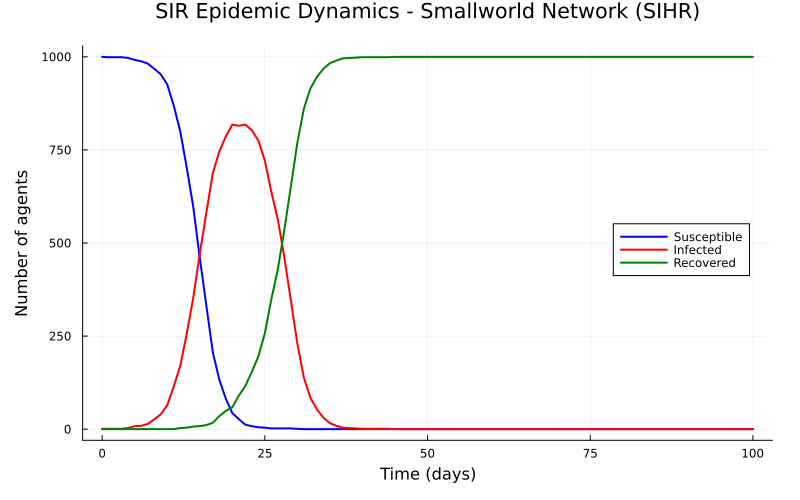

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\baseline_sihr.pdf"

In [2]:
include("src/plotting.jl")

model_sihr = initialize(;
    network_type=:smallworld,
    mean_degree=10,
    patient_zero=:random,
    use_hospitalization=true,
    hospitalization_prob=0.15,
    days_to_hospital_recovery=7,
)

adata = [:status]
mdata = [:susceptible_count, :infected_count, :hospitalized_count, :recovered_count]
_, mdf_sihr = run!(model_sihr, 100; adata, mdata)

p_sihr = plot_epidemic_trajectories(mdf_sihr, :smallworld; title_suffix=" (SIHR)")
display(p_sihr)
savefig(p_sihr, joinpath(FIGURES_DIR, "baseline_sihr.pdf"))

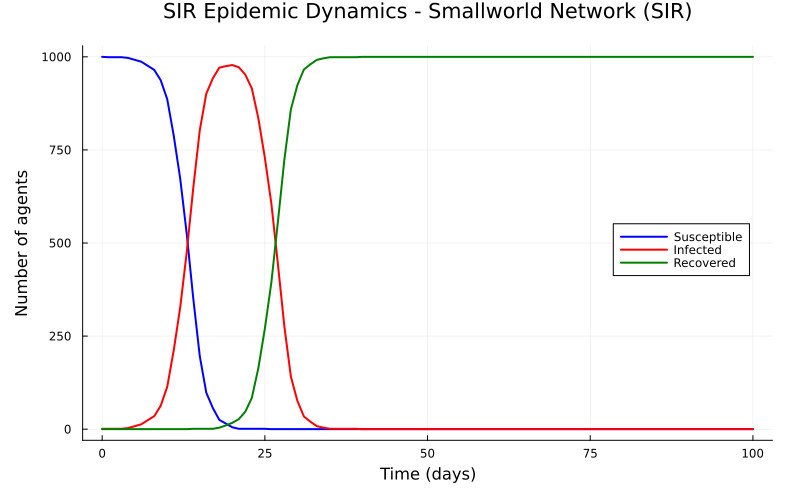

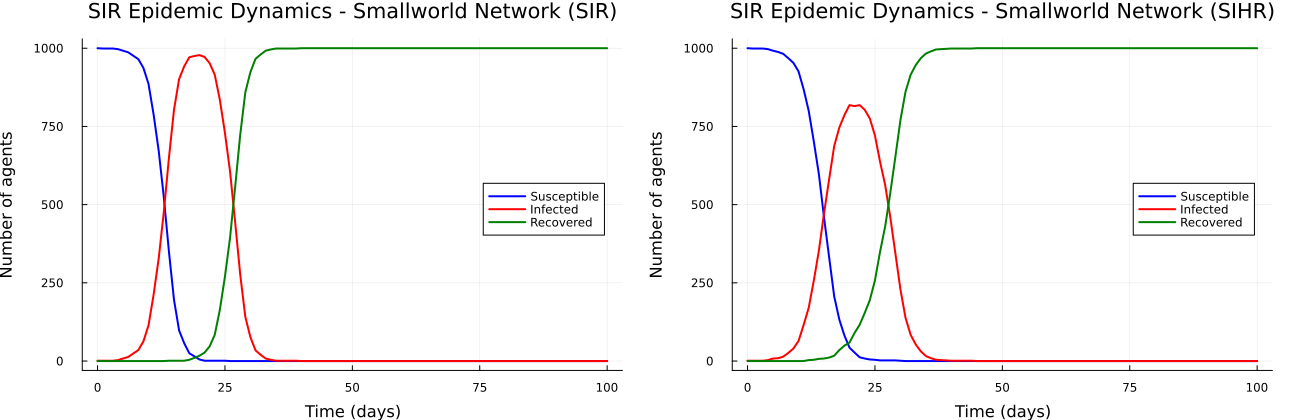

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\sir_vs_sihr.pdf"

In [3]:
model_sir = initialize(;
    network_type=:smallworld,
    mean_degree=10,
    patient_zero=:random,
    use_hospitalization=false,
)

mdata_sir = [:susceptible_count, :infected_count, :recovered_count]
_, mdf_sir = run!(model_sir, 100; adata, mdata=mdata_sir)

p_sir = plot_epidemic_trajectories(mdf_sir, :smallworld; title_suffix=" (SIR)")
display(p_sir)

p_compare = plot(p_sir, p_sihr, layout=(1,2), size=(1300, 420), margin=5Measures.mm)
display(p_compare)
savefig(p_compare, joinpath(FIGURES_DIR, "sir_vs_sihr.pdf"))

**Observation:** In SIHR, a fraction of infected agents are removed to hospital and stop transmitting. This typically lowers the peak infection count and the total circulating infections relative to SIR, while the **hospitalized** compartment tracks the burden on the healthcare system. That hospitalized signal is exactly what will drive the behavioral response in the next section.

---
## Section B: Hospitalization-Driven Contact Restriction

Now we let individuals respond to the outbreak. Each day, every individual who has **not yet** adopted contact-restricting behavior draws a single Bernoulli trial for whether to adopt it. The probability of adopting depends on the fraction of the community currently hospitalized,

$$s = \frac{\text{hospitalized}}{N},$$

through a **logistic** function:

$$p_{\text{adopt}}(s) = \frac{\text{max\_prob}}{1 + e^{-\alpha\,(s - \beta)}}.$$

- **α (`behavior_alpha`)** — *slope*: how sharply adoption switches on as hospitalizations climb.
- **β (`behavior_beta`)** — *mid-point*: the hospitalized fraction at which adoption reaches half of its ceiling. Smaller β → people react earlier.
- **max_prob (`behavior_max_prob`)** — the ceiling on the daily adoption probability.

Adoption is **absorbing**: once someone restricts their contacts they keep doing so, and a restricting individual **halves their contacts** (`contact_reduction = 0.5`). Because a contact involves two people, the transmission probability across a contact is scaled by `(1 - contact_reduction)` for *each* restricting endpoint — so adoption both throttles infectious individuals and protects susceptible ones.

We compare a no-behavior baseline against the three parameter sets suggested for this scenario:

| Scenario | α | β | max_prob |
|----------|------|--------|----------|
| Baseline | — (off) | — | — |
| Behavior 1 | 250 | 0.015 | 0.3 |
| Behavior 2 | 300 | 0.0175 | 0.3 |
| Behavior 3 | 400 | 0.020 | 0.3 |

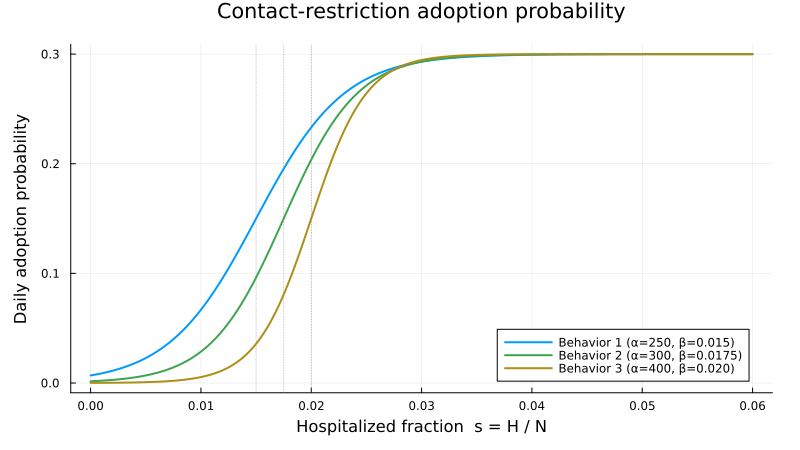

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\adoption_probability_curves.pdf"

In [4]:
# Visualize the daily adoption probability as a function of the hospitalized fraction.
# Each curve is the logistic p_adopt(s) for one parameter set.
behavior_sets = [
    ("Behavior 1 (α=250, β=0.015)",  250.0, 0.015, 0.3),
    ("Behavior 2 (α=300, β=0.0175)", 300.0, 0.0175, 0.3),
    ("Behavior 3 (α=400, β=0.020)",  400.0, 0.020, 0.3),
]

logistic_adopt(s, α, β, maxp) = maxp / (1 + exp(-α * (s - β)))

s_grid = range(0, 0.06; length=300)   # hospitalized fraction, 0% to 6%
p_curves = plot(xlabel="Hospitalized fraction  s = H / N",
    ylabel="Daily adoption probability",
    title="Contact-restriction adoption probability",
    legend=:bottomright, size=(800, 450), margin=5Measures.mm)

for (label, α, β, maxp) in behavior_sets
    plot!(p_curves, s_grid, logistic_adopt.(s_grid, α, β, maxp);
        label=label, linewidth=2)
    vline!(p_curves, [β]; label="", linestyle=:dot, color=:gray, alpha=0.4)
end

display(p_curves)
savefig(p_curves, joinpath(FIGURES_DIR, "adoption_probability_curves.pdf"))

### Running the scenarios

We now run the full model (SIHR + behavior) for the baseline and the three parameter sets, each over many random seeds, and compare the epidemic trajectories. The behavioral feedback should bend the curves: as the hospitalized compartment grows, more individuals restrict their contacts, throttling transmission and flattening the outbreak.

In [5]:
include("src/run_simulations.jl")
include("src/plotting.jl")

# (label, use_behavior_adoption, α, β); max_prob fixed at 0.3, contact_reduction at 0.5
scenarios = [
    ("Baseline (no behavior)",       false, 0.0,   0.0),
    ("Behavior 1 (α=250, β=0.015)",  true,  250.0, 0.015),
    ("Behavior 2 (α=300, β=0.0175)", true,  300.0, 0.0175),
    ("Behavior 3 (α=400, β=0.020)",  true,  400.0, 0.020),
]

results_behavior = Dict{String,Any}()
for (label, use_beh, α, β) in scenarios
    println("Running: $(label) ...")
    results_behavior[label] = run_simulations(;
        network_type=:smallworld,
        mean_degree=10,
        patient_zero=:random,
        use_hospitalization=true,
        hospitalization_prob=0.15,
        days_to_hospital_recovery=7,
        use_behavior_adoption=use_beh,
        behavior_alpha=α,
        behavior_beta=β,
        behavior_max_prob=0.3,
        contact_reduction=0.5,
    )
end
println("Done.")

Running: Baseline (no behavior) ...
Running: Behavior 1 (α=250, β=0.015) ...
Running: Behavior 2 (α=300, β=0.0175) ...
Running: Behavior 3 (α=400, β=0.020) ...
Done.


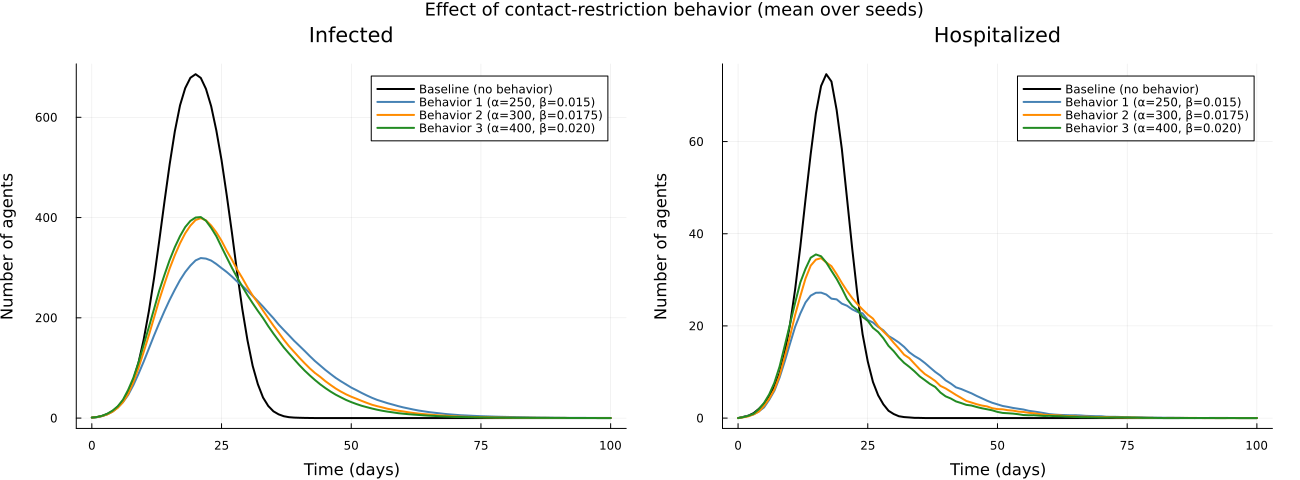

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\behavior_trajectories.pdf"

In [6]:
# Mean infected and hospitalized trajectories across seeds, one curve per scenario.
scenario_labels = first.(scenarios)
scenario_colors = [:black, :steelblue, :darkorange, :forestgreen]

p_inf  = plot(title="Infected",     xlabel="Time (days)", ylabel="Number of agents", legend=:topright)
p_hosp = plot(title="Hospitalized", xlabel="Time (days)", ylabel="Number of agents", legend=:topright)

for (label, col) in zip(scenario_labels, scenario_colors)
    mdf = results_behavior[label]
    mean_traj = combine(groupby(mdf, :time),
        :infected_count     => mean => :mean_inf,
        :hospitalized_count => mean => :mean_hosp,
    )
    sort!(mean_traj, :time)
    plot!(p_inf,  mean_traj.time, mean_traj.mean_inf;  label=label, linewidth=2, color=col)
    plot!(p_hosp, mean_traj.time, mean_traj.mean_hosp; label=label, linewidth=2, color=col)
end

p_traj = plot(p_inf, p_hosp, layout=(1,2), size=(1300, 480), margin=5Measures.mm,
    plot_title="Effect of contact-restriction behavior (mean over seeds)",
    plot_titlefontsize=12)
display(p_traj)
savefig(p_traj, joinpath(FIGURES_DIR, "behavior_trajectories.pdf"))

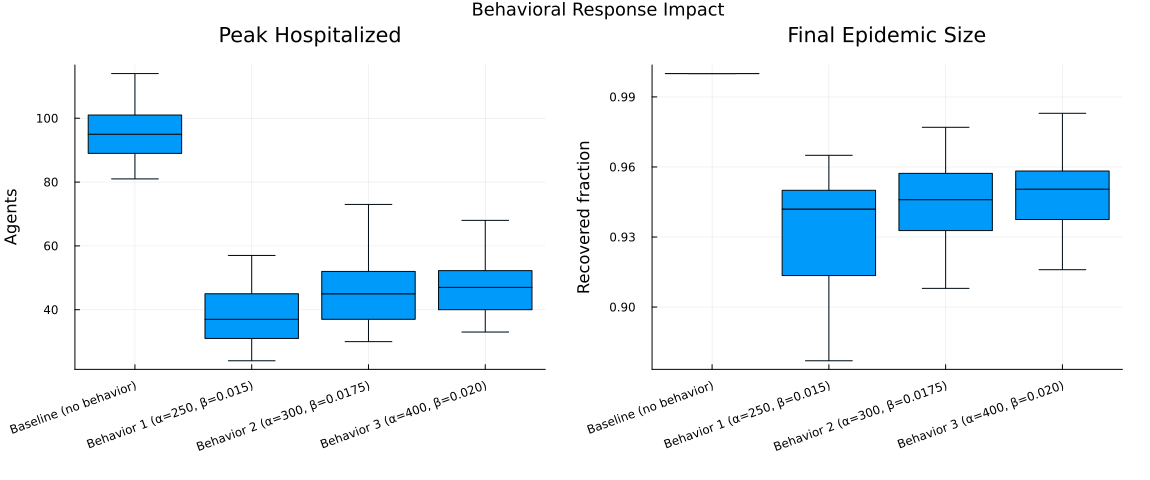

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\behavior_boxes.pdf"

In [7]:
# Per-seed summary metrics: peak hospitalized burden and final epidemic size.
peak_hosp_beh  = DataFrame(value=Float64[], scenario=String[])
final_size_beh = DataFrame(value=Float64[], scenario=String[])

for label in scenario_labels
    mdf = results_behavior[label]
    for gdf in groupby(mdf, :seed)
        last_row = last(gdf)
        total = last_row.susceptible_count + last_row.infected_count +
                last_row.hospitalized_count + last_row.recovered_count
        push!(peak_hosp_beh,  (maximum(gdf.hospitalized_count), label))
        push!(final_size_beh, (last_row.recovered_count / total, label))
    end
end

# Ordered categorical so the boxplots follow the scenario order
for df in (peak_hosp_beh, final_size_beh)
    df.scenario = CategoricalArray(df.scenario; ordered=true, levels=scenario_labels)
end

bp_peak = boxplot(peak_hosp_beh.scenario, peak_hosp_beh.value;
    title="Peak Hospitalized", ylabel="Agents", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)
bp_size = boxplot(final_size_beh.scenario, final_size_beh.value;
    title="Final Epidemic Size", ylabel="Recovered fraction", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)

p_boxes = plot(bp_peak, bp_size, layout=(1,2), size=(1150, 480),
    plot_title="Behavioral Response Impact", plot_titlefontsize=12,
    bottom_margin=16Measures.mm)
display(p_boxes)
savefig(p_boxes, joinpath(FIGURES_DIR, "behavior_boxes.pdf"))

---
## Interpretation

- **The behavioral feedback flattens the outbreak.** Once the hospitalized fraction climbs past the mid-point β, adoption of contact restriction accelerates, transmission is throttled, and the infected and hospitalized peaks drop relative to the baseline.
- **Earlier, sharper responses help most.** A smaller β (people react at a lower hospitalization level) and a larger α (a sharper switch) bring the response forward and cut the peak further. Comparing the three parameter sets, the one that triggers earliest leaves the most susceptibles uninfected (smallest final size).
- **Self-limiting, not eliminating.** Because adoption is capped at `max_prob` per day and only halves contacts, the behavior slows and shrinks the epidemic but does not stop it outright — a realistic feature of voluntary, severity-driven distancing. As the outbreak recedes the hospitalized signal falls, but already-adopted individuals keep restricting (the state is absorbing).

### Things to try
- Raise `behavior_max_prob` toward `1.0`, or lower `behavior_beta`, and watch the peak collapse.
- Increase `contact_reduction` toward `1.0` (a stronger personal cut) and weigh it against broader-but-weaker adoption.
- Change `mean_degree` or switch `patient_zero` to `:maxdegree` to see how the contact structure interacts with the behavioral response.